In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import ScalarFormatter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

import compute_metrics as cm
import degrade_profiles as dp

## Configuration


In [ ]:
#lines to analyse
lines = ['Fe6173', 'Fe5250', 'Fe6152', 'Fe6271']

#pretty names for plots
line_titles = {
    'Fe6173': 'Fe I 617.3 nm',
    'Fe5250': 'Fe I 525.0 nm',
    'Fe6152': 'Fe I 615.2 nm',
    'Fe6271': 'Fe I 627.1 nm',
}

#wavelengths of lines (nm)
line_wavelengths = {
    'Fe6173': np.loadtxt('../line_creation/data/Fe6173/wl_air.txt'),
    'Fe5250': np.loadtxt('../line_creation/data/Fe5250/wl_air.txt'),
    'Fe6152': np.loadtxt('../line_creation/data/Fe6152/wl_air.txt'),
    'Fe6271': np.loadtxt('../line_creation/data/Fe6271/wl_air.txt'),
}

#location of results (grid directory)
results_dir = '../grids/solar_inc90/output_data'

#metrics to compute
features = {
    "Equivalent Width [m/s]": cm.compute_equivalent_width,
    "Normalised Line Depth": cm.compute_core_depth,
    "FWHM [m/s]": cm.compute_fwhm,
}

#instrumental resolution to degrade to 
#Original profiles are at R=2,000,000
#Espresso UHR mode = 190,000
resolution = 190000


In [3]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],  
    'font.size': 16,                    
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20
})

## Features/RV correlation plot


=== Processing Fe6173 ===

=== Processing Fe5250 ===

=== Processing Fe6152 ===

=== Processing Fe6271 ===


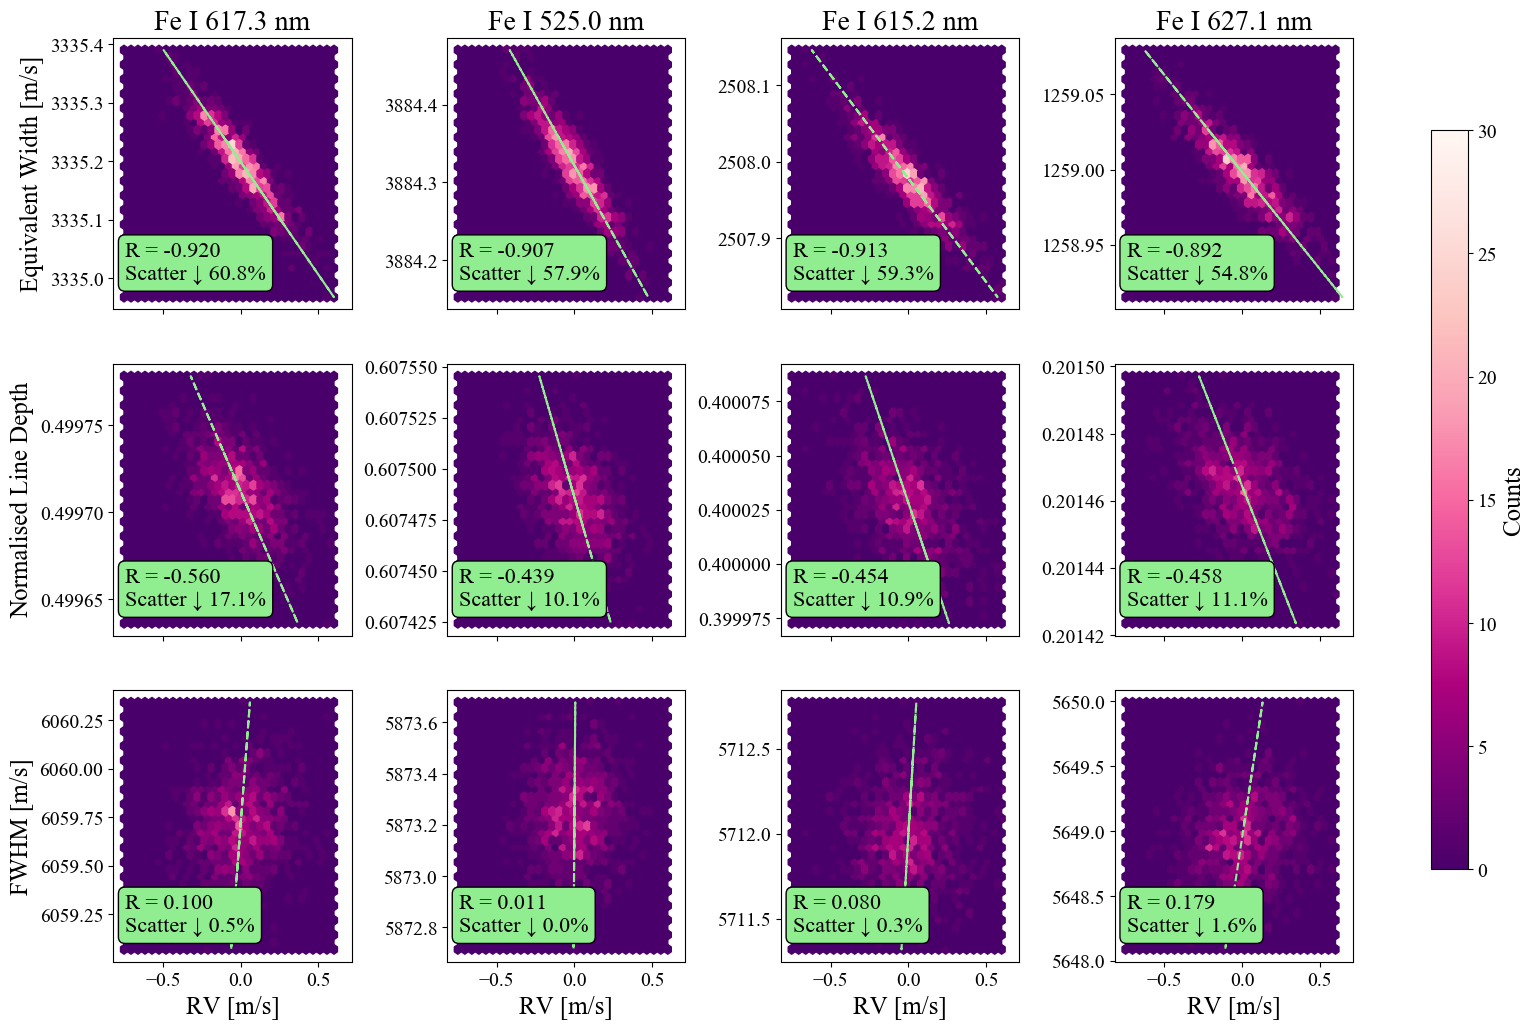

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True)
plt.subplots_adjust(hspace=0.2, wspace=0.4)

hb = None  # placeholder for the last hexbin

for col, line in enumerate(lines):
    print(f"\n=== Processing {line} ===")
    Is = np.load(f'{results_dir}/{line}_DI_1000.npy')
    Is = [Is[i]/np.max(Is[i]) for i in range(len(Is))]
    wl_og = line_wavelengths[line]

    #degrade to specified resolution
    wl = dp.degrade_and_rebin(wl_og, Is[0], R=resolution)[0]
    Is = [dp.degrade_and_rebin(wl_og, I, R=resolution)[1] for I in Is]
    mean_Is = np.mean(Is, axis=0)
    vel = (wl - np.median(wl)) / np.median(wl) * 299792458 #convert wl to velocity (m/s)

    rv_ccfs = np.array([np.real(cm.get_rv(wl, I, mean_Is)) for I in Is])

    for row, (fname, ffunc) in enumerate(features.items()):
        feats = np.array([ffunc(vel, I) for I in Is]).reshape(-1, 1)

        model = LinearRegression()
        model.fit(feats, rv_ccfs)
        rv_pred = model.predict(feats)

        rv_corrected = rv_ccfs - rv_pred
        rms_before = np.std(rv_ccfs, ddof=1)
        rms_after = np.std(rv_corrected, ddof=1)
        scatter_red = (rms_before - rms_after) / rms_before * 100
        R = np.corrcoef(feats.flatten(), rv_ccfs)[0, 1]

        ax = axes[row, col]
        hb = ax.hexbin(
            rv_ccfs, feats.flatten(),
            gridsize=30, cmap="RdPu_r",
            extent=(-0.75, 0.6, feats.flatten().min(), feats.flatten().max()),
            vmin=0,  
            vmax = 30
        )

        ax.plot(rv_pred, feats, '--', color="lightgreen", label="Fit")
        ax.set_title(f"{line_titles[line]}" if row == 0 else "")
        if col == 0:
            ax.set_ylabel(f"{fname}")
        ax.set_xlabel("RV [m/s]" if row == 2 else "")

        textstr = f"R = {R:.3f}\nScatter ↓ {scatter_red:.1f}%"
        ax.text(0.05, 0.25, textstr, transform=ax.transAxes,
                fontsize=16, verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor='lightgreen', edgecolor='black'))

# one shared colorbar for the whole figure
cbar = fig.colorbar(hb, ax=axes, orientation="vertical", shrink=0.8)
cbar.set_label("Counts")

for ax in axes.flat:
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style='plain', axis='x')
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style='plain', axis='y')

plt.savefig('output_plots/feature_vs_RV_all_lines.png', bbox_inches='tight', dpi=300)
plt.show()


## Linear regression model results


=== Processing Fe6173 ===

=== Processing Fe5250 ===

=== Processing Fe6152 ===

=== Processing Fe6271 ===


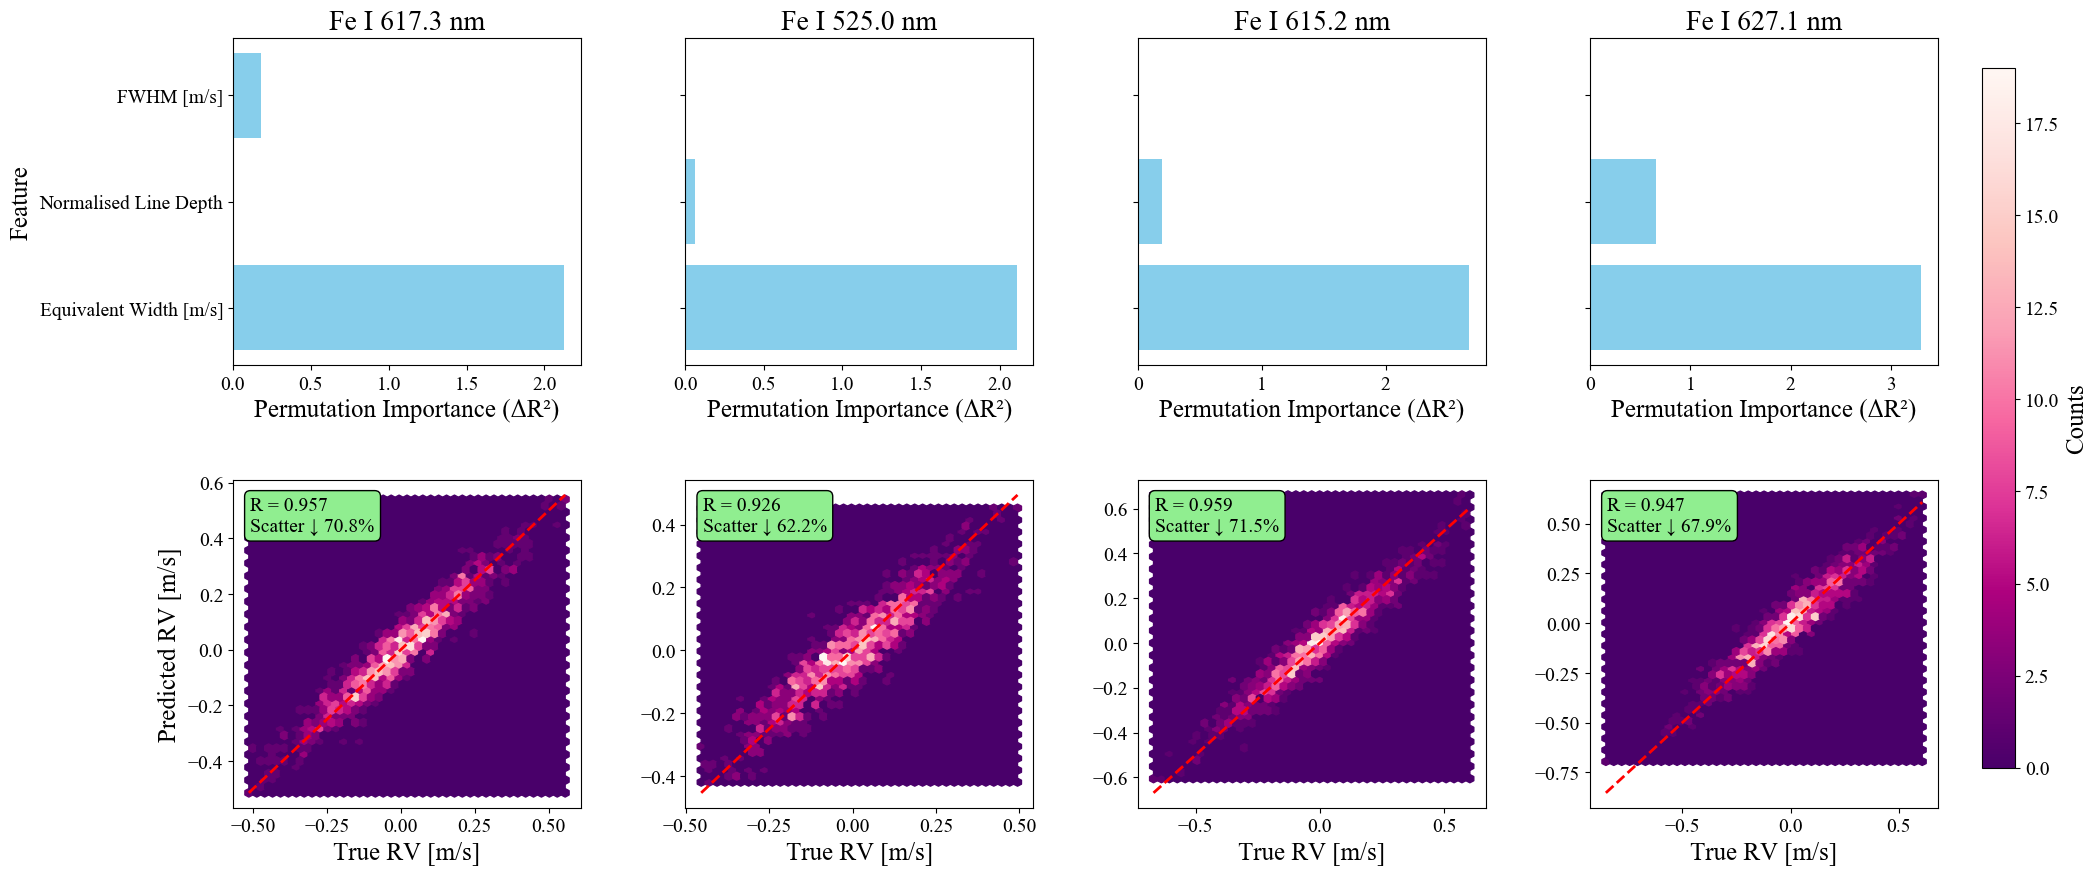

In [ ]:

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

hb = None 

for col, line in enumerate(lines):
    print(f"\n=== Processing {line} ===")
    Is_test = np.load(f'{results_dir}/{line}_DI_1000.npy')
    Is_train = np.load(f'{results_dir}/{line}_DI_1000_train.npy')

    #normalise
    Is_test = [Is_test[i]/np.max(Is_test[i]) for i in range(len(Is_test))]
    Is_train = [Is_train[i]/np.max(Is_train[i]) for i in range(len(Is_train))]

    wl_og = line_wavelengths[line]

    # degrade to specified resolution
    wl = dp.degrade_and_rebin(wl_og, Is_train[0], R=resolution)[0]
    Is_train = [dp.degrade_and_rebin(wl_og, I, R=resolution)[1] for I in Is_train]
    Is_test = [dp.degrade_and_rebin(wl_og, I, R=resolution)[1] for I in Is_test]

    mean_Is_train = np.mean(Is_train, axis=0)
    mean_Is_test = np.mean(Is_test, axis=0)

    y_train = np.array([np.real(cm.get_rv(wl, I, mean_Is_train)) for I in Is_train])
    y_test = np.array([np.real(cm.get_rv(wl, I, mean_Is_test)) for I in Is_test])

    vel = (wl - np.mean(wl)) / np.mean(wl) * 299792458  # m/s

    # === Feature matrix ===
    all_feats_train = np.column_stack([
        [ffunc(vel, I) for I in Is_train] for _, ffunc in features.items()
    ])

    all_feats_test = np.column_stack([
        [ffunc(vel, I) for I in Is_test] for _, ffunc in features.items()
    ])

    feat_names = list(features.keys())

    # === Scale features ===
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(all_feats_train)
    X_test_scaled = scaler.transform(all_feats_test)

    # === Train regression ===
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # === Metrics ===
    R = np.corrcoef(y_test, y_pred)[0, 1]
    rms_before = np.std(y_test, ddof=1)
    rms_after = np.std(y_test - y_pred, ddof=1)
    scatter_red = (rms_before - rms_after) / rms_before * 100

    # === Row 1: Feature importance (permutation importance) ===
    result = permutation_importance(model, X_test_scaled, y_test, n_repeats=100, random_state=42)
    importances = result.importances_mean

    ax1 = axes[0, col]
    ax1.barh(feat_names, importances, color="skyblue")
    ax1.set_title(line_titles[line])
    if col == 0:
        ax1.set_ylabel("Feature")
    else:
        ax1.set_yticklabels([])  # hide redundant labels
    ax1.set_xlabel("Permutation Importance (ΔR²)")

    # === Row 2: Predicted vs True RV ===
    ax2 = axes[1, col]
    hb = ax2.hexbin(y_test, y_pred, gridsize=40, cmap="RdPu_r")
    ax2.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2)
    ax2.set_xlabel("True RV [m/s]")
    if col == 0:
        ax2.set_ylabel("Predicted RV [m/s]")

    # Green annotation box
    textstr = f"R = {R:.3f}\nScatter ↓ {scatter_red:.1f}%"
    ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes,
             fontsize=14, verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor='lightgreen', edgecolor='black'))

# === Shared colorbar outside the grid ===
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(hb, cax=cbar_ax)
cbar.set_label("Counts")

plt.savefig("output_plots/rv_prediction_summary_permutation.png", dpi=300, bbox_inches="tight")
plt.show()
